In [8]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import glob

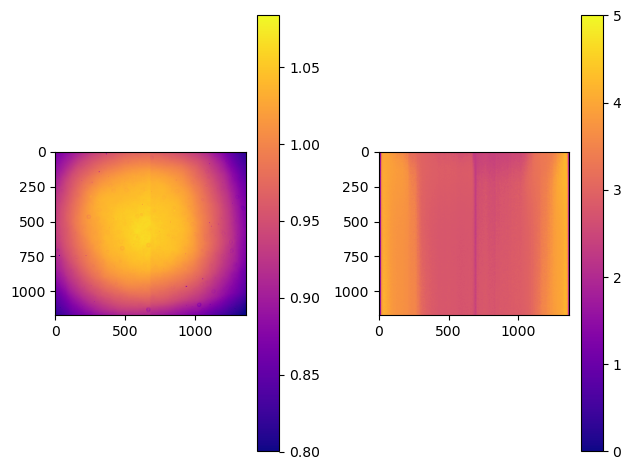

In [12]:
sflat_fits = fits.open('sflat.fits')
bias_fits = fits.open('bias.fits')

fig, ax = plt.subplots(1,2)
plot1 = ax[0].imshow(sflat_fits[0].data, cmap='plasma', vmin=0.8)
plot2 = ax[1].imshow(bias_fits[0].data, cmap='plasma', vmin=0, vmax=5)
fig.colorbar(plot1)
fig.colorbar(plot2)
fig.tight_layout() # totally pointless, but a good overview of the flat and bias frames

sflat = sflat_fits[0].data
bias = bias_fits[0].data

sflat_fits.close()
bias_fits.close()

In [20]:
# okay, now we need to do something serious. Take in each raw image, perform the reduction transformation, and create a new fits file
# with the same header and the reduced image

# I don't want to glob anything. Ugh, but it's going to be easier
filepath_list = glob.glob('../Jupyter Notebooks/Astro302/final_project_fits/*.fits') # fetch all fits files as a glob in the project folder

for file in filepath_list: # iterate through all raw images
    image = fits.open(file)
    science_image = (image[0].data - bias)/sflat # create reduced image
    header = image[0].header
    filename = file.split('\\')[-1] # just the *.fits component of the filepath
    new_filepath = 'reduced_images/'+filename # destination filepath

    # where the cosmic ray removal would go if I did it
    
    hdu = fits.PrimaryHDU(data = science_image, header = header)
    hdu.writeto(new_filepath)

    image.close() # figure out what to do for cosmic ray removal here